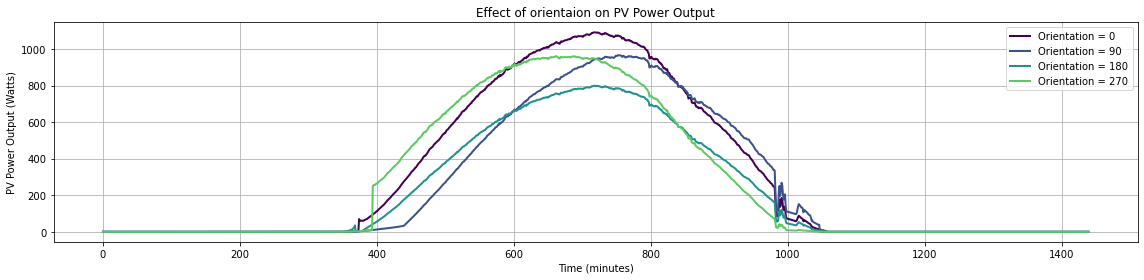

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from math import cos, sin, tan, acos, asin, atan, radians, degrees, log10

# 时间定义
n = np.array([275])
st = np.arange(1, 24*60+1)

# 读取太阳辐射数据
Rt_h = pd.read_excel('SR.xlsx').values[1440:2880, :].flatten()
Rd_h = 0.85 * Rt_h
Rs_h = 0.15 * Rt_h

# 读取环境温度数据
T = pd.read_excel('T.xlsx').values[1440:2880, :].flatten()

# 光伏电池参数
Tref = 25 #多晶硅电池标准工况温度 ℃
eta_ref = 0.20 #多晶硅电池标准工况发电效率
c1, c2, c3 = -3.75, 1.14, 0.0175 
rou = 0.0045 # 多晶硅电池升温效率衰减系数 
sigma = 0.1

Ppv_cals = []

gammas = np.array([0, 90, 180, 270]) # %方位角，角度 北360 东90 南180 西270 

for gamma in gammas:
    beita = 15
    fai = 30 + 16/60

    # 太阳高度角计算
    cos_theta = np.zeros(len(T))
    sin_a = np.zeros(len(T))
    a = np.zeros(len(T))
    A = np.zeros(len(T))

    for i in range(len(T)):
        temp = np.ceil(i / 1440)
        n_n = n[int(temp-1)]
        st_t = (i % 1440) / 60

        omega = radians(15 * (st_t - 12))
        derta = radians(23.45 * sin(2 * np.pi * ((284 + n_n) / 365)))
        sin_a[i] = sin(radians(fai)) * sin(derta) + cos(radians(fai)) * cos(derta) * cos(omega)
        a[i] = degrees(asin(sin_a[i]))

        A[i] = degrees(atan(sin(omega) / (cos(radians(fai)) * tan(derta) - sin(radians(fai)) * cos(omega))))
        cos_theta[i] = (sin(radians(fai)) * cos(radians(beita)) - cos(radians(fai)) * cos(radians(gamma)) * sin(radians(beita))) * sin(derta) + (cos(radians(fai)) * cos(radians(beita)) + sin(radians(fai)) * cos(radians(gamma)) * sin(radians(beita))) * cos(derta) * cos(omega) + sin(radians(gamma)) * sin(radians(beita)) * cos(derta) * sin(omega)

    # 平面太阳辐射转化为倾斜面太阳辐射  因为太阳辐射散射与直射部分按一定比例从总水平面太阳辐射取得，Rd_h=0.85*Rt_h; Rs_h=0.15*Rt_h; 
    # 会导致太阳刚出时及太阳快下山时的直射辐射比实际数值偏大，导致倾斜面直射太阳辐射计算数值出现跃升。需要抛出跃升数值。
    # 若分别有散射与直射测量数值，直接分别代入程序计算即可，不需要如下循环。
    Rd = np.zeros(len(T))
    for i in range(len(T)):
        if cos_theta[i] / sin_a[i] <= 4 and cos_theta[i] / sin_a[i] >= 0:
            Rd[i] = Rd_h[i] * cos_theta[i] / sin_a[i]
        else:
            Rd[i] = 0

    Rr = 0.15 * Rt_h * (1 - cos(radians(beita))) / 2 # 倾斜面反射太阳辐射量 0.15 为地面平均反射率
    Rs = Rs_h * (1 + cos(radians(beita))) / 2 #倾斜面散射太阳辐射量  LJ 模型：典型的各向同性模型。将散射辐射视为仅由穹顶散射构成，倾斜面上的散射辐照度与其面对的穹顶面积成正比
    Rt = Rd + Rs + Rr

    # 光伏发电功率计算
    Ppv = np.zeros(len(T))
    for i in range(len(T)):
        if Rt[i] > 0:
            Ppv[i] = Rt[i] * eta_ref * (1 - rou * (c1 + c2 * T[i] + c3 * Rt[i] - Tref) + sigma * log10(Rt[i])) # 参考(Solar Energy, Volume 83, Issue 5, 2009)
        else:
            Ppv[i] = 0

    Ppv_cal = 9 * 0.496 * Ppv
    Ppv_cals.append(Ppv_cal)

# 绘制结果
plt.figure(figsize=(16, 4))
colors = plt.get_cmap('viridis')
for j, gamma in enumerate(gammas):
    plt.plot(Ppv_cals[j], color=colors(j / len(gammas)), linewidth=2, label=f'Orientation = {gamma}')
plt.xlabel('Time (minutes)')
plt.ylabel('PV Power Output (Watts)')
plt.title('Effect of orientaion on PV Power Output')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save the figure with high resolution
# plt.savefig('PV_Output.png', dpi=300)


In [7]:
np.ceil(1441 / 1440)

2.0